# **DETERMINE THE MAGNETIC FIELD REQUIREMENTS BASED ON SATELLITE TLE**

Change root directory

In [1]:
import os
root_dir = os.path.dirname(os.path.abspath(''))
os.chdir(root_dir)
print(f"Directory changed to: {os.getcwd()}")

Directory changed to: /home/bespi123/git/helmholtzCoilsDesigner


## **IMPORT LIBRARIES**

In [2]:
import pandas as pd
from datetime import datetime, timedelta
from src import satSimulationMagField as sim
from src import plotMagneticField as hplot

# **General Satellite Example**

**Run Satellite Orbit Propagator**

In [3]:
# TLE of the satellite
line1 = "1 00000U 20000A   25015.00000000  .00000000  00000-0  00000-0 0  9991"
line2 = "2 00000  97.3400 313.1310 0000000  0.0000  0.0000 15.09556778000000"

# Simulation parameters
start_date = datetime(2025, 1, 15)
end_date = start_date + timedelta(days=100)
time_step = timedelta(hours=0.08)
batch_size = 50

# Run the simulation
sim.initialize_satellite(line1, line2)
df = sim.simulate_satellite(start_date, end_date, time_step, batch_size)

# Save results to CSV
df.to_csv("data/satellite_propagation_results.csv", index=False)
print("Results saved to 'satellite_propagation_results.csv'")

Results saved to 'satellite_propagation_results.csv'


**Plot results**

In [4]:
df = pd.read_csv('data/satellite_propagation_results.csv')
values = sim.calculate_max_min_values(df, 'ECI')

Max Value Bx ECI (nT): 45839.86895741893 nT, Min Value Bx ECI (nT): -45342.45177870458 nT
Max Value By ECI (nT): 46208.256178266194 nT, Min Value By ECI (nT): -34046.21391202095 nT
Max Value Bz ECI (nT): 44894.94890550539 nT, Min Value Bz ECI (nT): -45448.63680014032 nT


In [5]:
hplot.plot_orbit(df, 'ECI')

In [6]:
hplot.plot_orbit(df, 'ECEF')

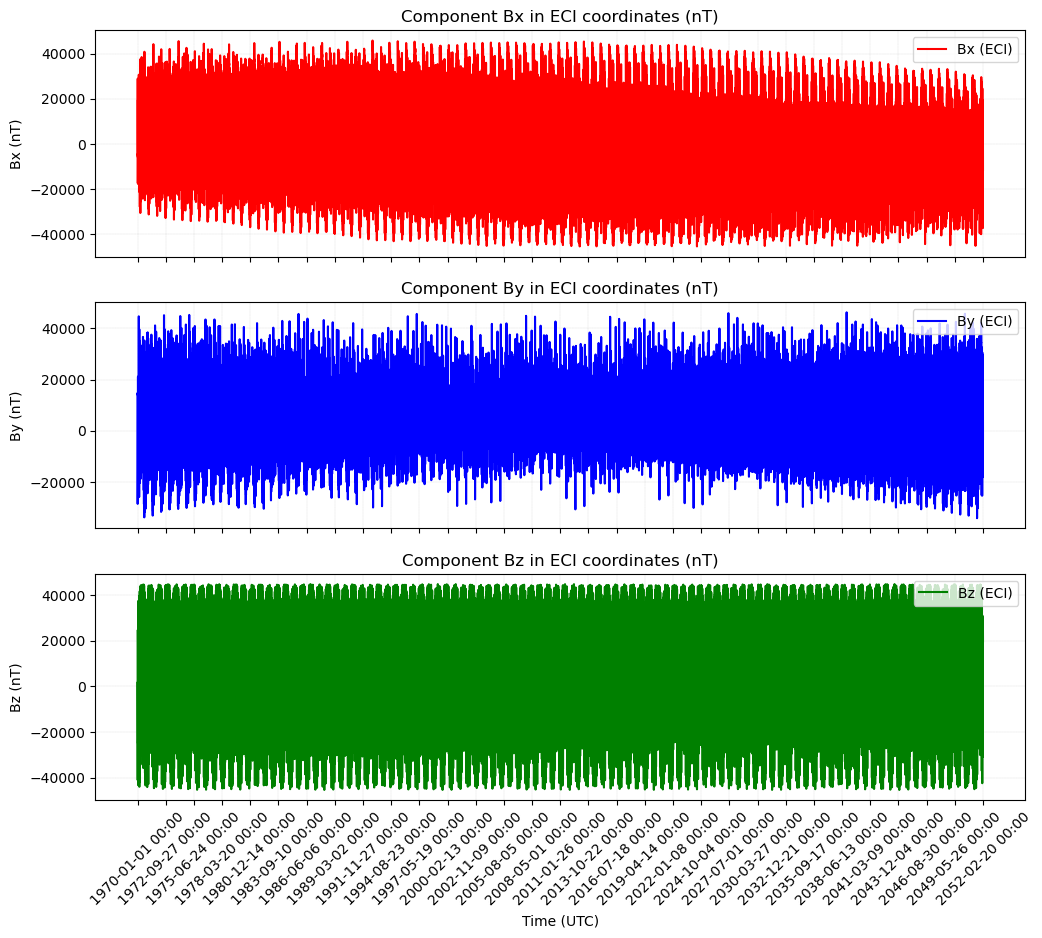

In [7]:
hplot.plot_magField_time(df, 'ECI')

# **Public Satellite Example**

In this example the satellite called AJISAI is tested to demonstrate the capabilities of the proposed software.
The satellite data is obtained from: https://celestrak.org/NORAD/elements/

**Run Satellite Orbit Propagator**

In [8]:
# TLE of the satellite
line1 = "1 16908U 86061A   25151.92740062 -.00000081  00000+0  11484-3 0  9999"
line2 = "2 16908  50.0088 239.7584 0011211 289.4678 181.8257 12.44512251432913"

# Simulation parameters
start_date = datetime(2025, 1, 15)
end_date = start_date + timedelta(days=100)
time_step = timedelta(hours=0.08)
batch_size = 50

# Run the simulation
sim.initialize_satellite(line1, line2)
df = sim.simulate_satellite(start_date, end_date, time_step, batch_size)

# Save results to CSV
df.to_csv("data/satellite_propagation_results_AJISAI.csv", index=False)
print("Results saved to 'satellite_propagation_results_AJISAI.csv'")

Results saved to 'satellite_propagation_results_AJISAI.csv'


**Plot results**

In [9]:
df = pd.read_csv('data/satellite_propagation_results_AJISAI.csv')
values = sim.calculate_max_min_values(df, 'ECI')

Max Value Bx ECI (nT): 31641.28280022241 nT, Min Value Bx ECI (nT): -31515.186338715543 nT
Max Value By ECI (nT): 31681.776724538377 nT, Min Value By ECI (nT): -31510.09644852509 nT
Max Value Bz ECI (nT): 30571.35854725172 nT, Min Value Bz ECI (nT): -23905.79790815516 nT


In [10]:
hplot.plot_orbit(df, 'ECI')

In [11]:
hplot.plot_orbit(df, 'ECEF')

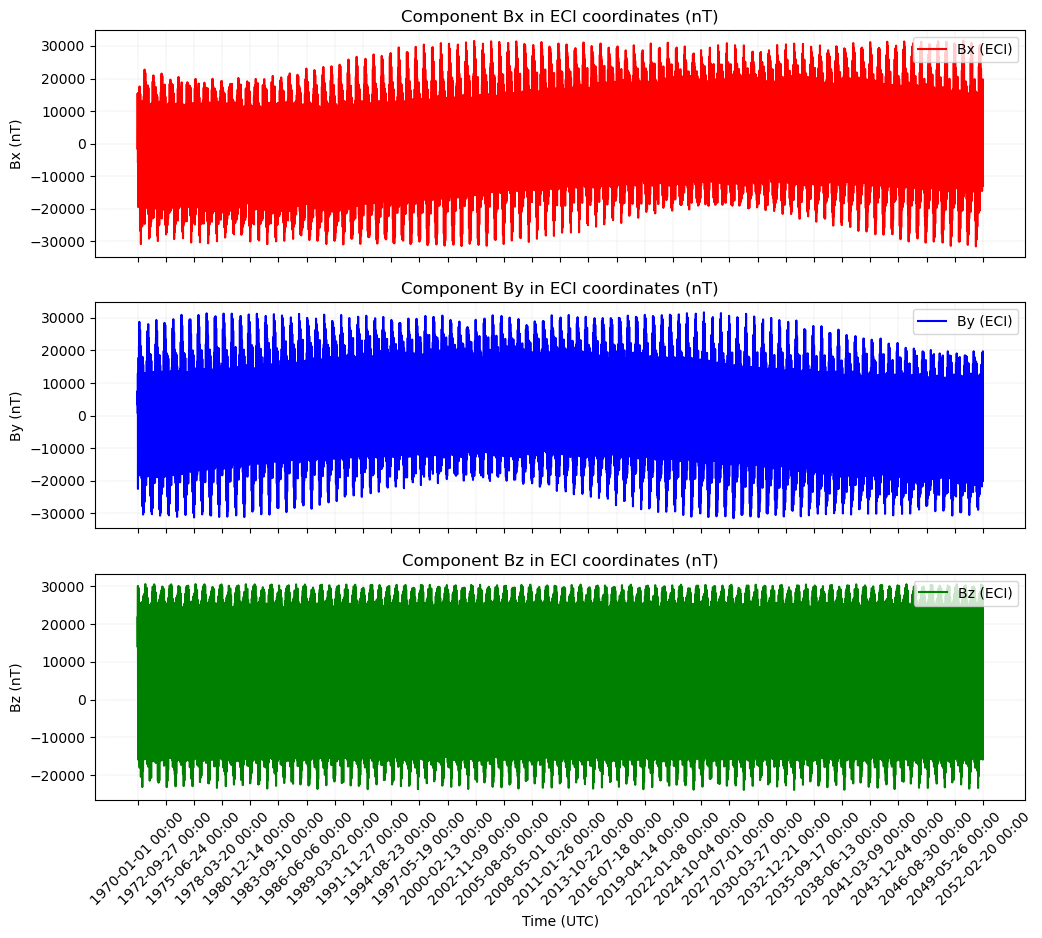

In [12]:
hplot.plot_magField_time(df, 'ECI')